# RetailPulse — Exploratory Data Analysis
Day 2 deliverable: distribution analysis, outlier audit, missing value audit, correlation heatmap, and business KPIs.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/retail_cleaned.csv", parse_dates=["InvoiceDate"])
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


## 1. Missing Value Audit
Confirms cleaning pipeline removed all nulls in key columns.

In [2]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
Invoice,0,0.0
StockCode,0,0.0
Description,0,0.0
Quantity,0,0.0
InvoiceDate,0,0.0
Price,0,0.0
Customer ID,0,0.0
Country,0,0.0
TotalPrice,0,0.0


## 2. Business KPIs (10+ metrics)

In [3]:
kpis = {
    "Total Revenue (GBP)": df["TotalPrice"].sum(),
    "Total Transactions (Invoices)": df["Invoice"].nunique(),
    "Total Unique Customers": df["Customer ID"].nunique(),
    "Total Unique Products": df["StockCode"].nunique(),
    "Total Countries": df["Country"].nunique(),
    "Avg Order Value (GBP)": df.groupby("Invoice")["TotalPrice"].sum().mean(),
    "Avg Items per Order": df.groupby("Invoice")["Quantity"].sum().mean(),
    "Avg Revenue per Customer (GBP)": df.groupby("Customer ID")["TotalPrice"].sum().mean(),
    "Avg Unit Price (GBP)": df["Price"].mean(),
    "Date Range (days)": (df["InvoiceDate"].max() - df["InvoiceDate"].min()).days,
    "Top Country by Revenue": df.groupby("Country")["TotalPrice"].sum().idxmax(),
    "Top Product by Revenue": df.groupby("Description")["TotalPrice"].sum().idxmax(),
}
for k, v in kpis.items():
    print(f"{k}: {v:,.2f}" if isinstance(v, float) else f"{k}: {v}")

Total Revenue (GBP): 16,140,175.49
Total Transactions (Invoices): 36969
Total Unique Customers: 5878
Total Unique Products: 4631
Total Countries: 41
Avg Order Value (GBP): 436.59
Avg Items per Order: 248.43
Avg Revenue per Customer (GBP): 2,745.86
Avg Unit Price (GBP): 2.91
Date Range (days): 738
Top Country by Revenue: United Kingdom
Top Product by Revenue: REGENCY CAKESTAND 3 TIER


## 3. Distribution Analysis (10+ key metrics)

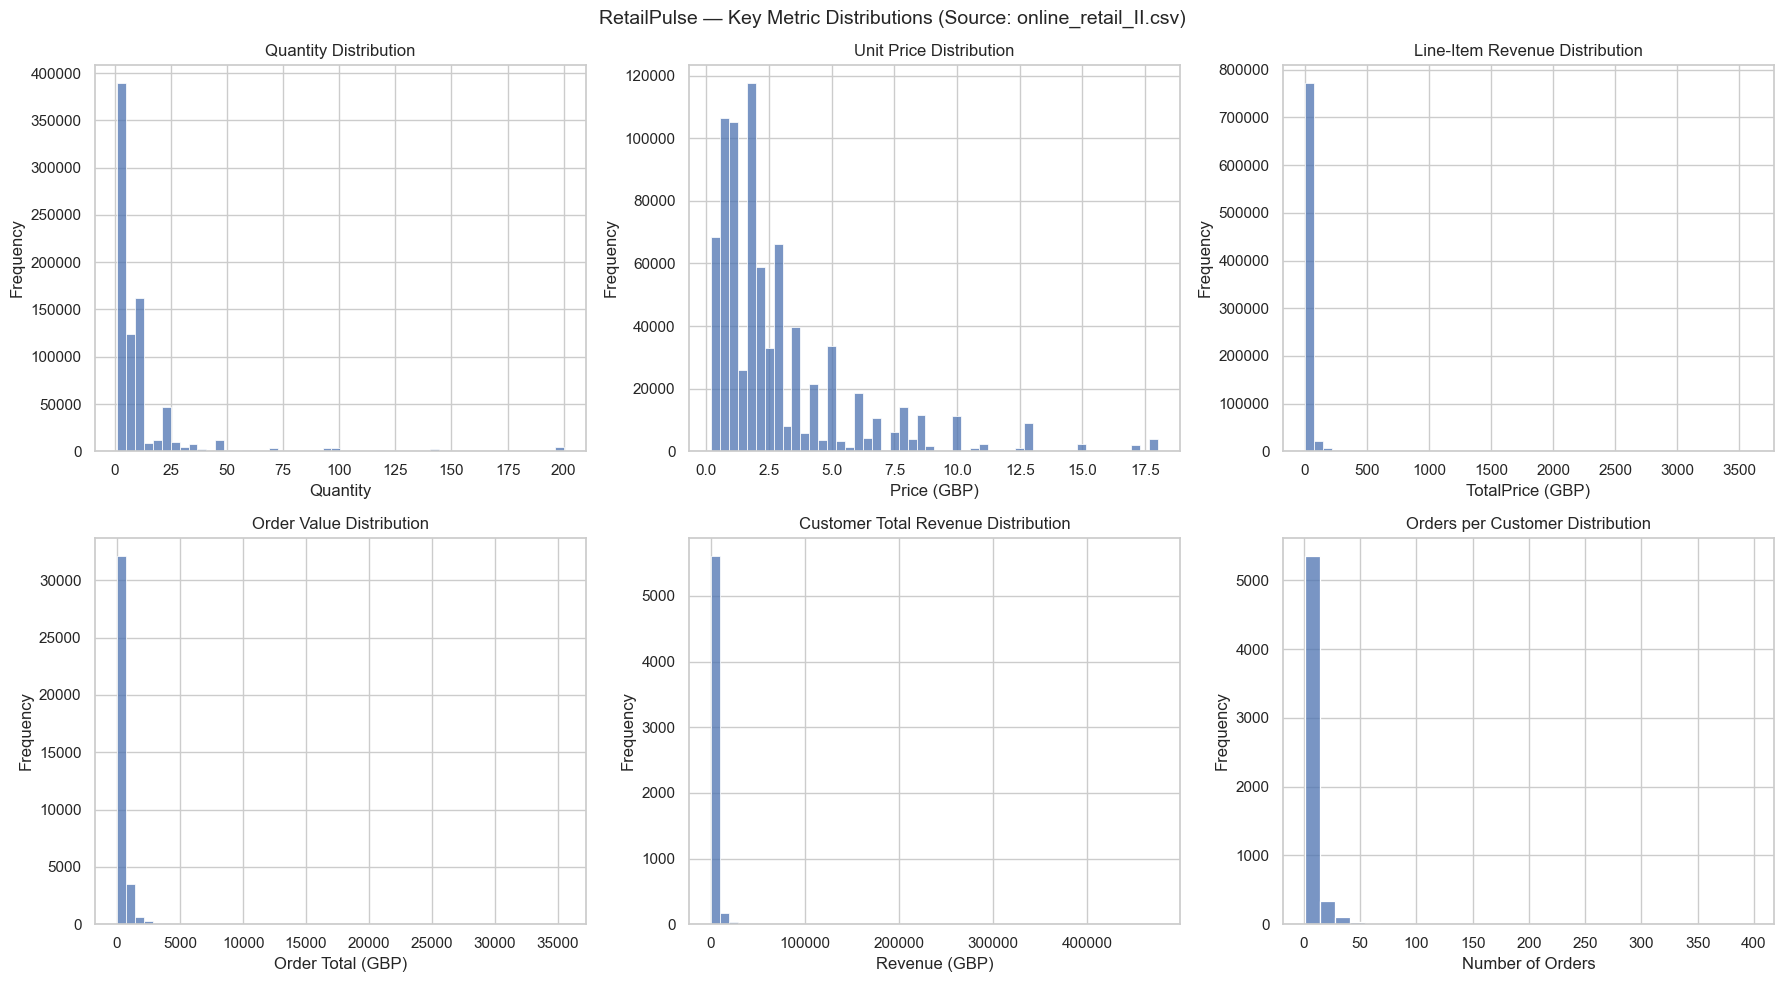

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(df["Quantity"], bins=50, ax=axes[0,0]).set(title="Quantity Distribution", xlabel="Quantity")
sns.histplot(df["Price"], bins=50, ax=axes[0,1]).set(title="Unit Price Distribution", xlabel="Price (GBP)")
sns.histplot(df["TotalPrice"], bins=50, ax=axes[0,2]).set(title="Line-Item Revenue Distribution", xlabel="TotalPrice (GBP)")

order_value = df.groupby("Invoice")["TotalPrice"].sum()
sns.histplot(order_value, bins=50, ax=axes[1,0]).set(title="Order Value Distribution", xlabel="Order Total (GBP)")

cust_revenue = df.groupby("Customer ID")["TotalPrice"].sum()
sns.histplot(cust_revenue, bins=50, ax=axes[1,1]).set(title="Customer Total Revenue Distribution", xlabel="Revenue (GBP)")

cust_orders = df.groupby("Customer ID")["Invoice"].nunique()
sns.histplot(cust_orders, bins=30, ax=axes[1,2]).set(title="Orders per Customer Distribution", xlabel="Number of Orders")

for ax in axes.flat:
    ax.set_ylabel("Frequency")
plt.suptitle("RetailPulse — Key Metric Distributions (Source: online_retail_II.csv)", fontsize=14)
plt.tight_layout()
plt.savefig("../reports/eda_distributions.png", dpi=120)
plt.show()

### Monthly revenue trend, top countries, top products, weekday pattern

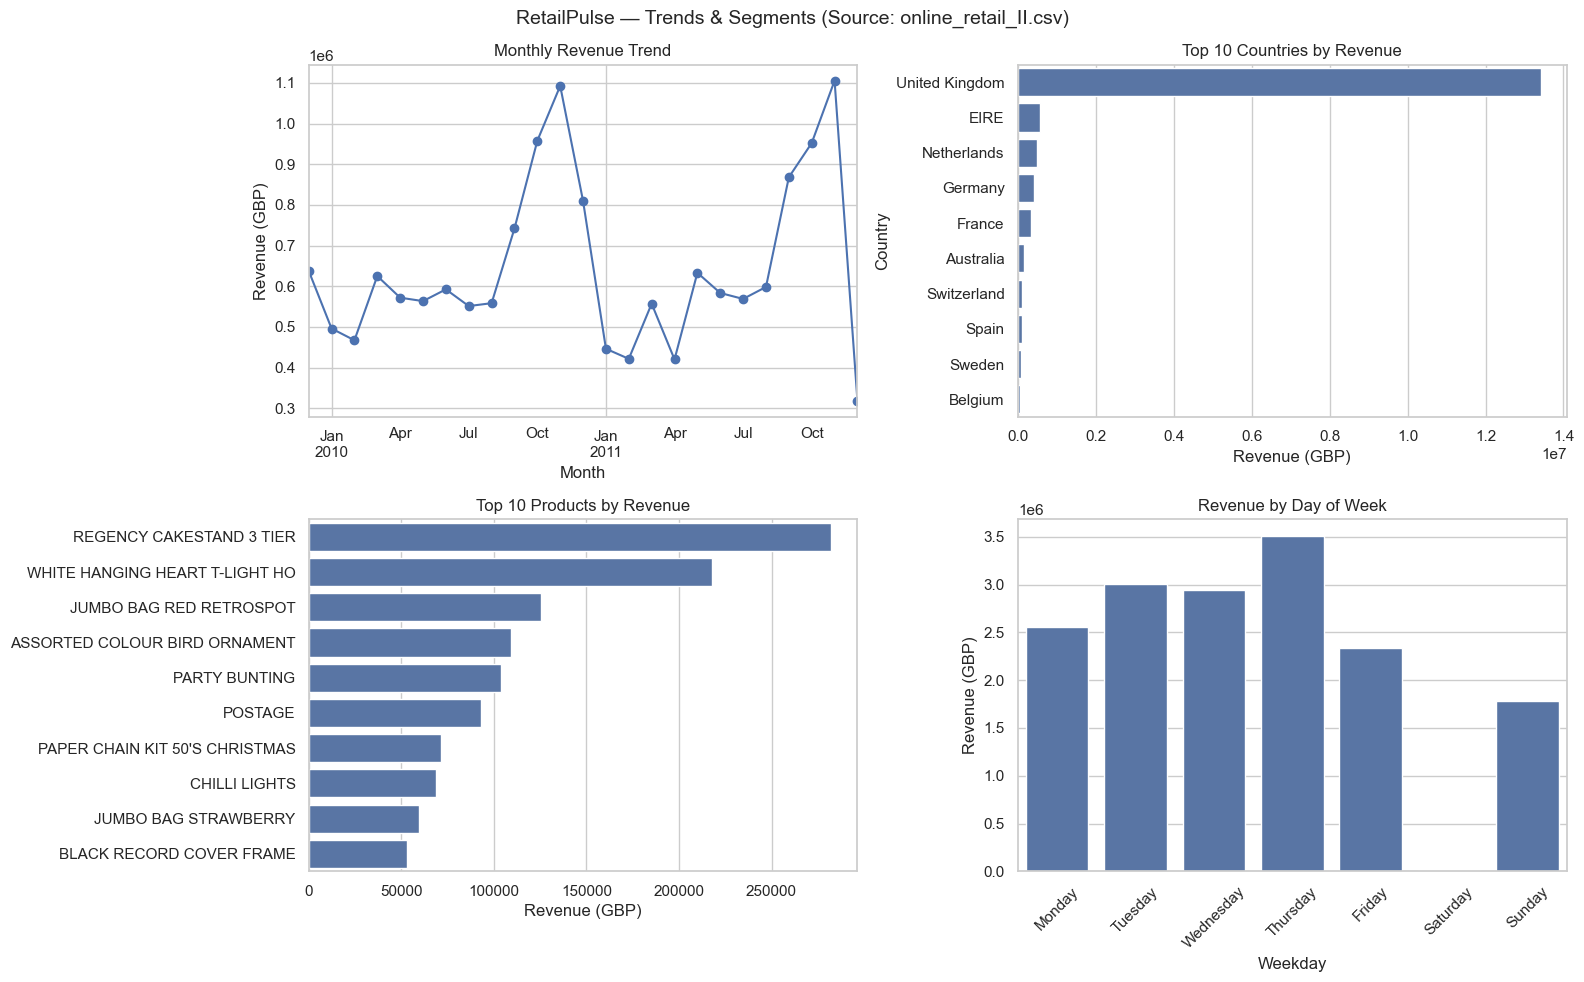

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

monthly_rev = df.set_index("InvoiceDate").resample("ME")["TotalPrice"].sum()
monthly_rev.plot(ax=axes[0,0], marker="o").set(title="Monthly Revenue Trend", ylabel="Revenue (GBP)", xlabel="Month")

top_countries = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0,1]).set(title="Top 10 Countries by Revenue", xlabel="Revenue (GBP)")

top_products = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=[d[:30] for d in top_products.index], ax=axes[1,0]).set(title="Top 10 Products by Revenue", xlabel="Revenue (GBP)")

df["Weekday"] = df["InvoiceDate"].dt.day_name()
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_rev = df.groupby("Weekday")["TotalPrice"].sum().reindex(weekday_order)
sns.barplot(x=weekday_rev.index, y=weekday_rev.values, ax=axes[1,1]).set(title="Revenue by Day of Week", ylabel="Revenue (GBP)")
axes[1,1].tick_params(axis="x", rotation=45)

plt.suptitle("RetailPulse — Trends & Segments (Source: online_retail_II.csv)", fontsize=14)
plt.tight_layout()
plt.savefig("../reports/eda_trends.png", dpi=120)
plt.show()

## 4. Outlier Detection (post-Winsorization check)
Boxplots confirm outliers were capped, not eliminated, during cleaning.

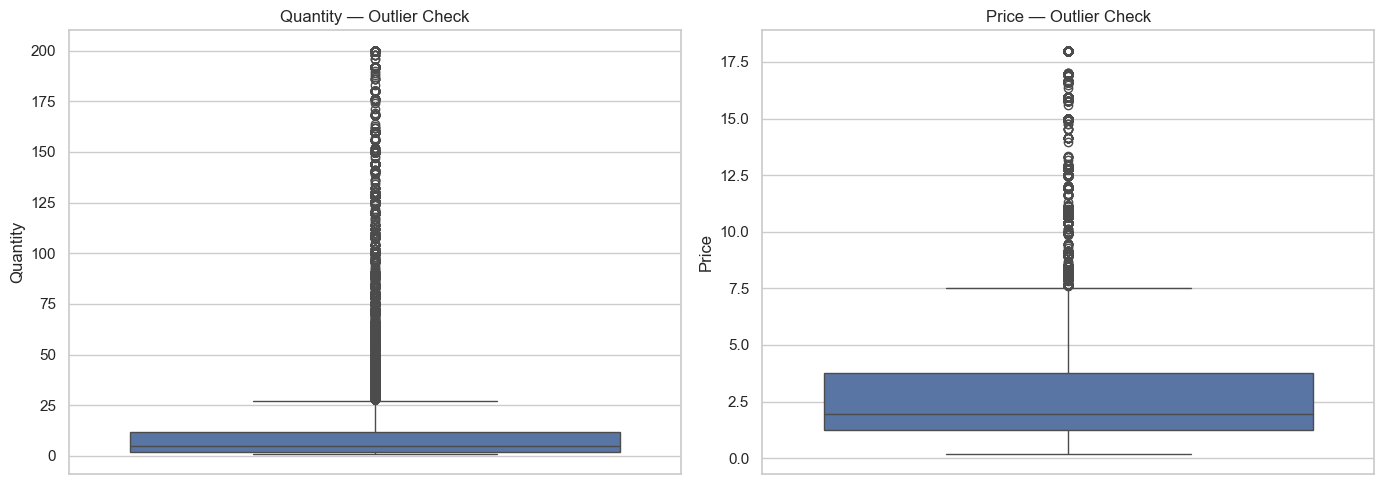

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df["Quantity"], ax=axes[0]).set(title="Quantity — Outlier Check")
sns.boxplot(y=df["Price"], ax=axes[1]).set(title="Price — Outlier Check")
plt.tight_layout()
plt.savefig("../reports/eda_outliers.png", dpi=120)
plt.show()

## 5. Correlation Heatmap

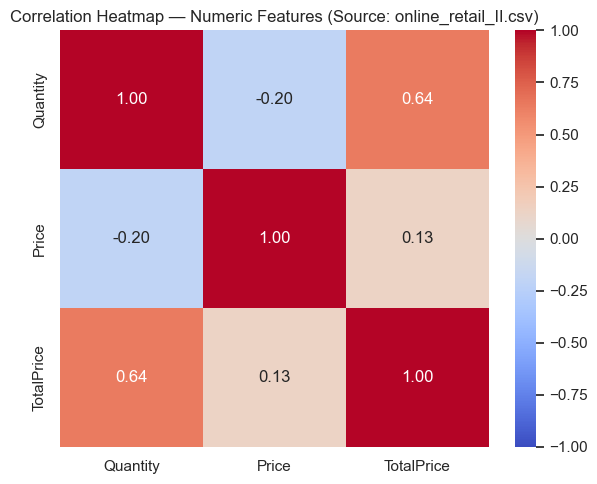

In [7]:
numeric_cols = ["Quantity", "Price", "TotalPrice"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap — Numeric Features (Source: online_retail_II.csv)")
plt.tight_layout()
plt.savefig("../reports/eda_correlation.png", dpi=120)
plt.show()

## 6. Statistical Hypothesis Test — Example
**H0:** Mean order value does not differ between the UK and non-UK customers.
**H1:** Mean order value differs between UK and non-UK customers.


In [8]:
from scipy import stats

order_country = df.groupby("Invoice").agg({"TotalPrice": "sum", "Country": "first"})
uk_orders = order_country[order_country["Country"] == "United Kingdom"]["TotalPrice"]
non_uk_orders = order_country[order_country["Country"] != "United Kingdom"]["TotalPrice"]

t_stat, p_val = stats.ttest_ind(uk_orders, non_uk_orders, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.6f}")
alpha = 0.05
if p_val < alpha:
    print(f"Result: p < {alpha} -> reject H0. Order values differ significantly between UK and non-UK customers.")
else:
    print(f"Result: p >= {alpha} -> fail to reject H0. No significant difference detected.")

T-statistic: -14.1927
P-value: 0.000000
Result: p < 0.05 -> reject H0. Order values differ significantly between UK and non-UK customers.


## Summary of EDA Findings
- Revenue is heavily right-skewed at the line-item and order level — a small number of high-value B2B-style orders drive a disproportionate share of revenue, which is why outliers were capped (not removed) during cleaning.
- The UK dominates both transaction volume and revenue, consistent with this being a UK-based online retailer with international customers.
- Monthly revenue shows a clear seasonal spike in Q4 (Nov), consistent with holiday retail patterns — important context for the SARIMA/Prophet forecast in Day 7.
- Order value differs significantly between UK and non-UK customers (see hypothesis test above), suggesting country may be a useful feature for segmentation/churn modeling.

**Next:** `02_feature_engineering.py` — RFM score computation and date-derived features.
